# Desafío - Modelos de Ensamble (Parte I)

**Nombre:** Ignacio Robles  
**Generación:** G-115 Data Science

## Introducción y Preguntas

El objetivo de este desafío es entrenar modelos de ensamble para predecir la renuncia de clientes en una empresa de telecomunicaciones.

### Preguntas / Tareas:

1. Importar librerías, cargar datos y realizar análisis exploratorio con visualizaciones, incluyendo un heatmap de correlaciones.
2. Desarrollar un modelo de árbol de decisión:
   - Sin modificar hiperparámetros
   - Optimizado con GridSearchCV (5-fold)
3. Balancear clases con SMOTE y aplicar Bagging con 200 estimadores.
4. Implementar Bagging heterogéneo con:
   - Regresión Logística
   - Árbol de decisión
   - SVM (rbf y sigmoid)
5. Implementar Random Forest con:
   - n_estimators = 45
   - Evaluación con OOB
6. Optimizar Random Forest con GridSearch:
   - n_estimators: 50 a 200
   - max_features: ['sqrt', 'log2', None]
7. Identificar los 15 clientes con mayor probabilidad de renunciar.


## Diccionario de Variables

| Variable | Descripción |
|----------|------------|
| Churn | Variable objetivo (1 = renuncia, 0 = permanece) |
| AccountWeeks | Semanas con cuenta activa |
| ContractRenewal | 1 si renovó contrato, 0 si no |
| DataPlan | 1 si tiene plan de datos |
| DataUsage | Uso mensual de datos (GB) |
| CustServCalls | Llamadas a servicio al cliente |
| DayMins | Minutos diurnos promedio |
| DayCalls | Llamadas diurnas promedio |
| MonthlyCharge | Cargo mensual promedio |
| OverageFee | Cargo extra por exceso |
| RoamMin | Minutos de roaming |


## Instrucciones del Desafío

- Utilizar modelos de clasificación supervisada.
- Aplicar visualización de datos (EDA).
- Implementar:
  - Árbol de decisión
  - Bagging
  - Random Forest
- Usar GridSearchCV con validación cruzada (5-fold).
- Balancear clases usando SMOTE.
- Evaluar modelos con métricas como accuracy, precision, recall, f1-score.
- Utilizar OOB score en Random Forest.
- Archivo a utilizar: `telecom_churn.csv`
- Para Bagging heterogéneo usar función `bagging_het` desde `util_bagging.py`.


In [42]:
# Configuración e imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from util_bagging import bagging_het, bagging_het_predict

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

from imblearn.over_sampling import SMOTE

# Configuramos pandas para poder leer más comodamente
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.width', 1000)

# Definimos nuestras variables universales para evitar errores al traspasar los datos
TEST_SIZE = 0.20
RANDOM_STATE = 42 # porque, es la respuesta a todo

# Carga de datos
df = pd.read_csv('telecom_churn.csv')

df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.10,110,89.00,9.87,10.00
1,0,107,1,1,3.70,1,161.60,123,82.00,9.78,13.70
2,0,137,1,0,0.00,0,243.40,114,52.00,6.06,12.20
3,0,84,0,0,0.00,2,299.40,71,57.00,3.10,6.60
4,0,75,0,0,0.00,3,166.70,113,41.00,7.42,10.10


## 1. Análisis Exploratorio de Datos


---
# Análisis Univariado y Multivariado

---

In [6]:
print("Estos son los tipos de datos presentes")
print(df.info())
print("\nEstos son los valores nulos presentes")
print(df.isnull().sum())
print("\nEstos son los datos descriptivos de las variables numéricas")
print(df.describe())

Estos son los tipos de datos presentes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB
None

Estos son los valores nulos presentes
Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls     

In [17]:
print("La distribución de la variable objetivo es:")
print(df['Churn'].value_counts())

La distribución de la variable objetivo es:
Churn
0    2850
1     483
Name: count, dtype: int64


Churn
0   0.86
1   0.14
Name: proportion, dtype: float64


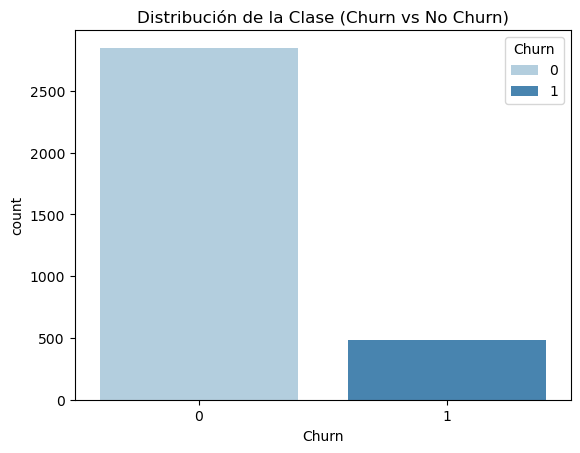

In [25]:
# ¿Qué tan grave es el desbalanceo?
print(df['Churn'].value_counts(normalize=True))
sns.countplot(x='Churn', data=df, hue='Churn',palette='Blues')
plt.title('Distribución de la Clase (Churn vs No Churn)')
plt.show()

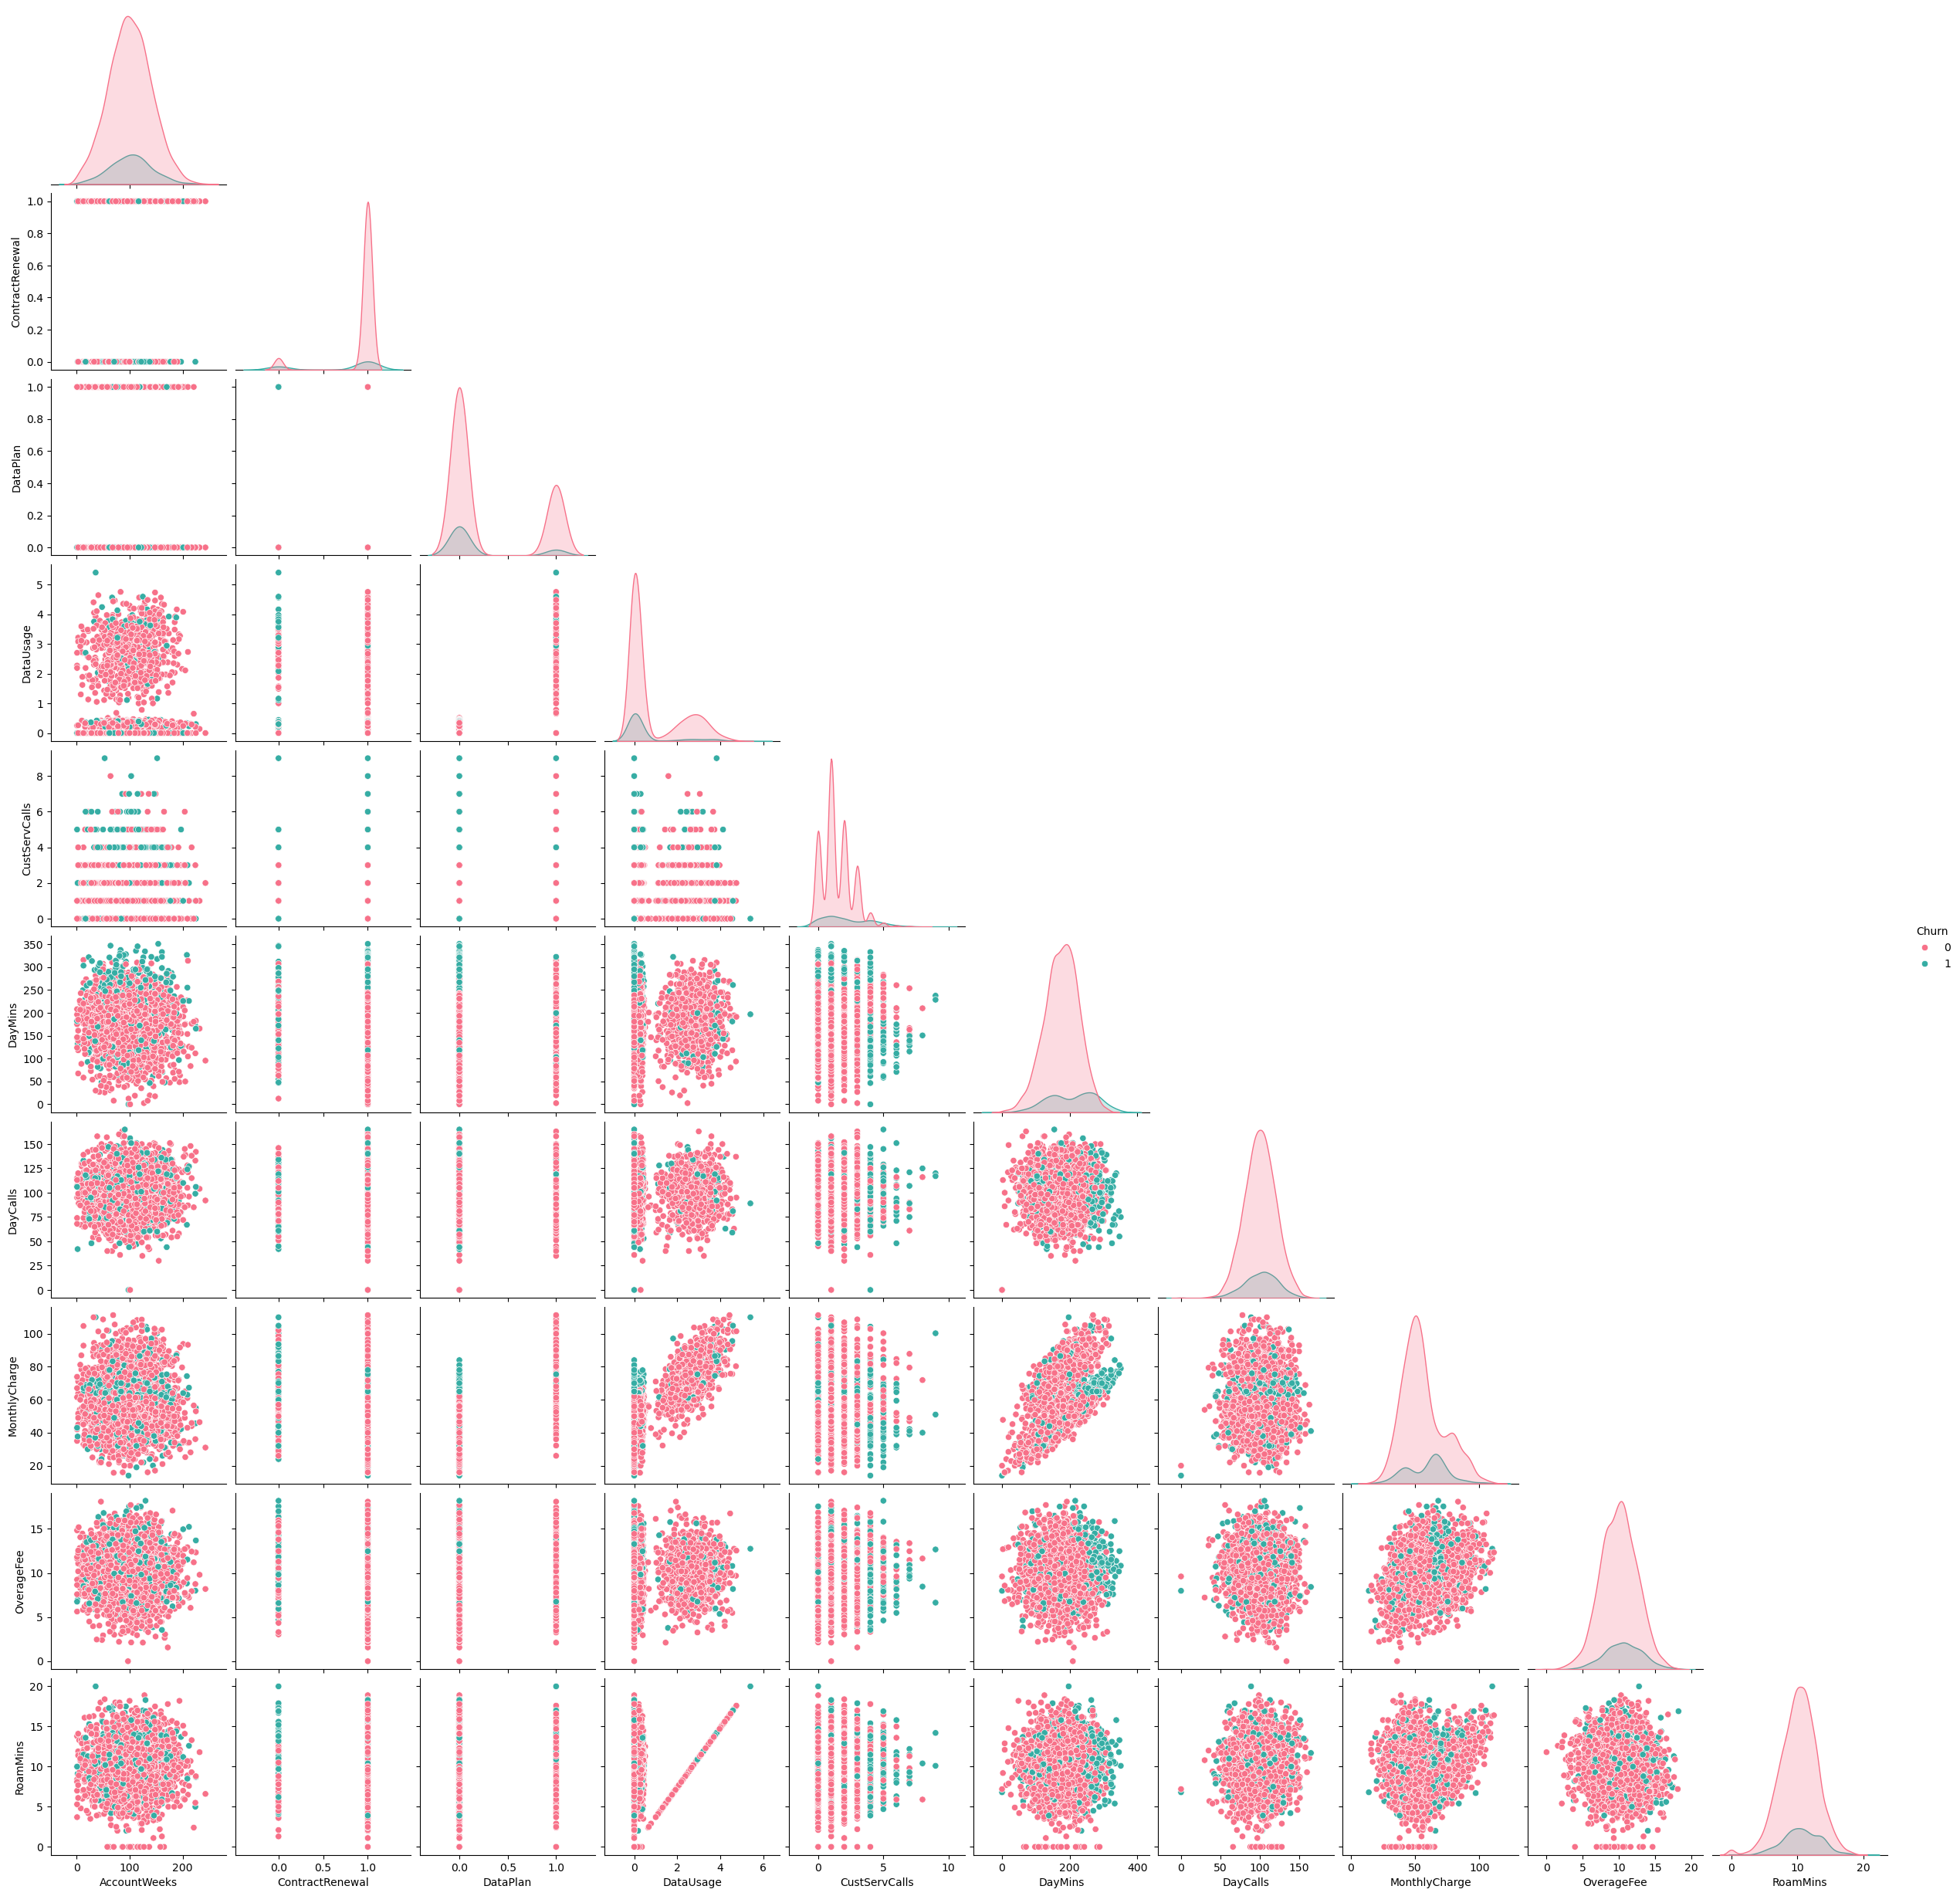

In [8]:
# El parámetro 'hue' es clave para ver patrones por clase
sns.pairplot(df, hue='Churn', palette='husl', corner=True)
plt.show()

In [10]:
# Vamos a hacer doble click en contract renewal, para poder revisar si es crítica.
print(df.groupby('ContractRenewal')['Churn'].mean())

ContractRenewal
0   0.42
1   0.11
Name: Churn, dtype: float64


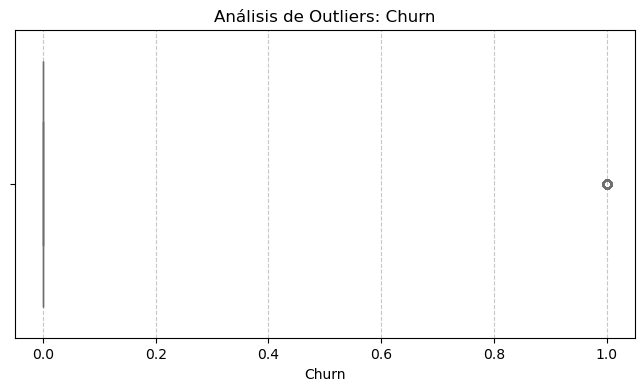

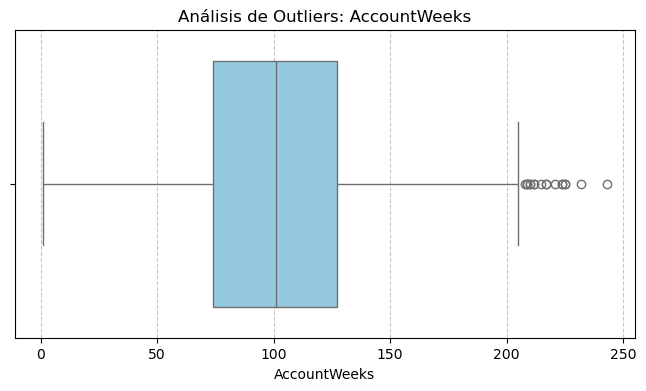

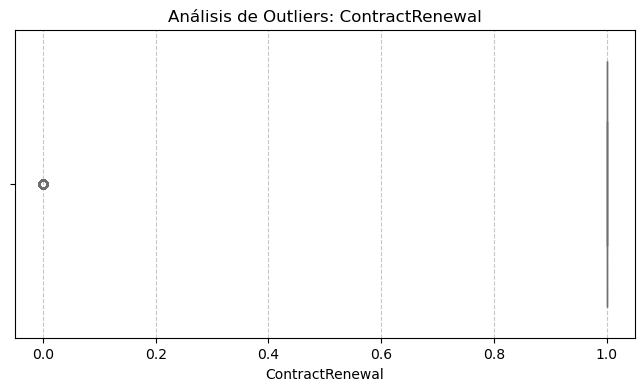

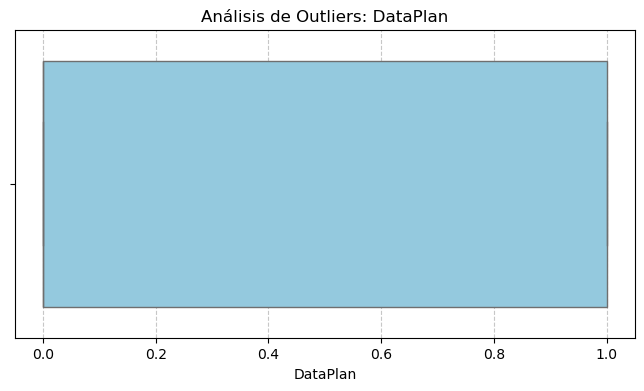

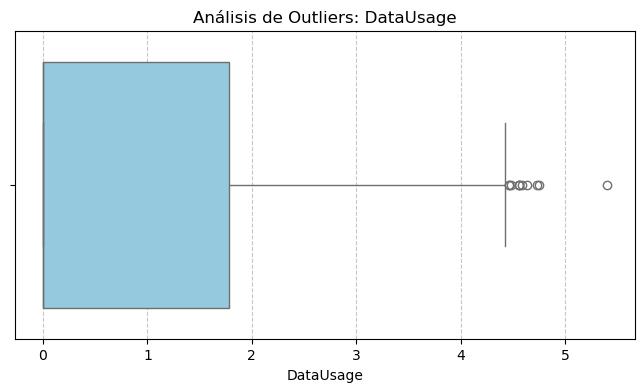

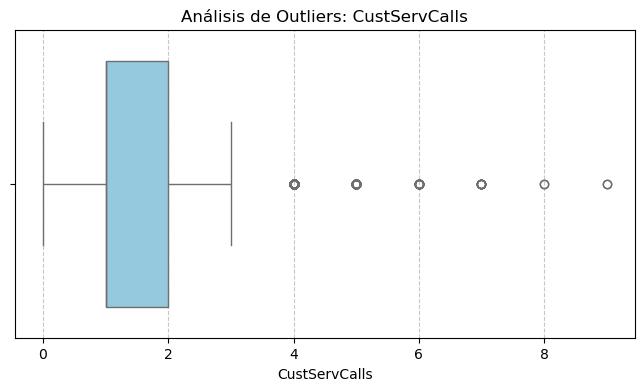

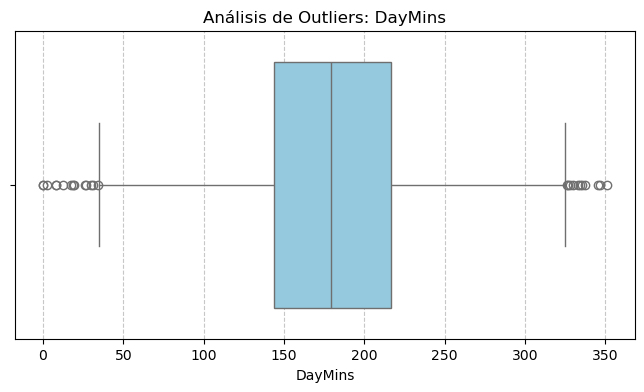

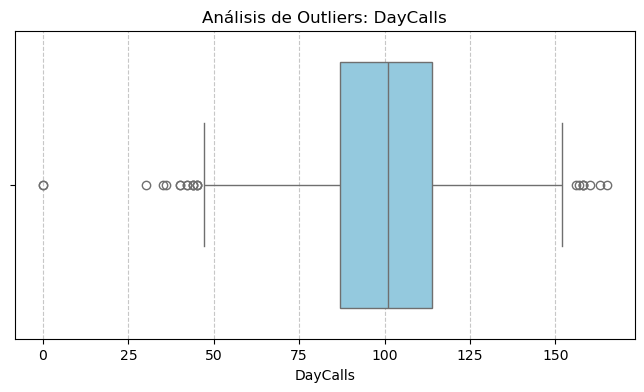

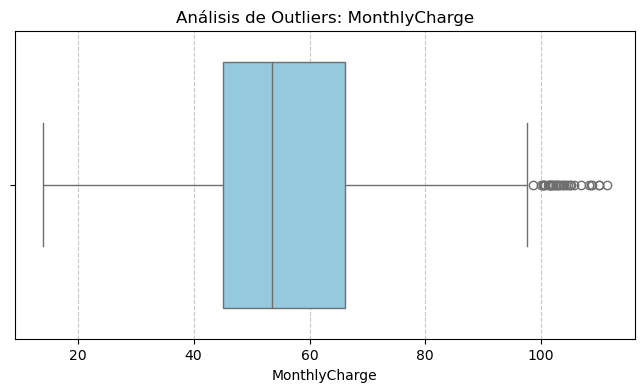

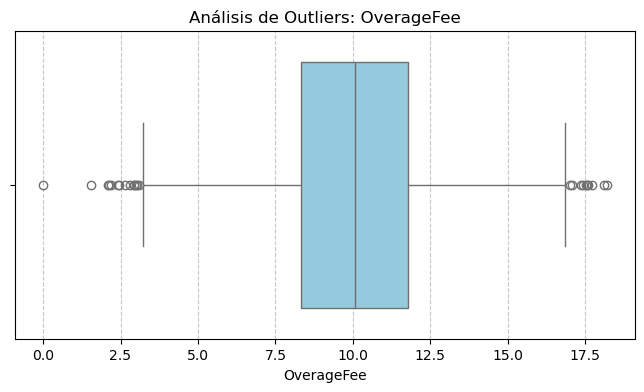

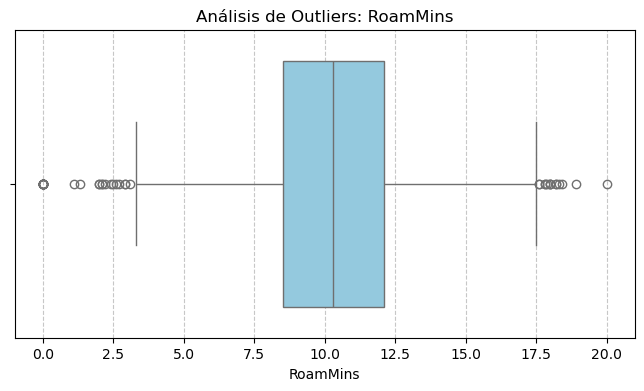

In [11]:
# 1. Filtramos solo las columnas numéricas (los boxplots no funcionan con categorías)
df_numerico = df.select_dtypes(include=['number'])

# 2. Iteramos por cada columna para crear un gráfico independiente
for col in df_numerico.columns:
    plt.figure(figsize=(8, 4)) # Ajusta el tamaño de la "celda"
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Análisis de Outliers: {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

---
# Heatmap

---

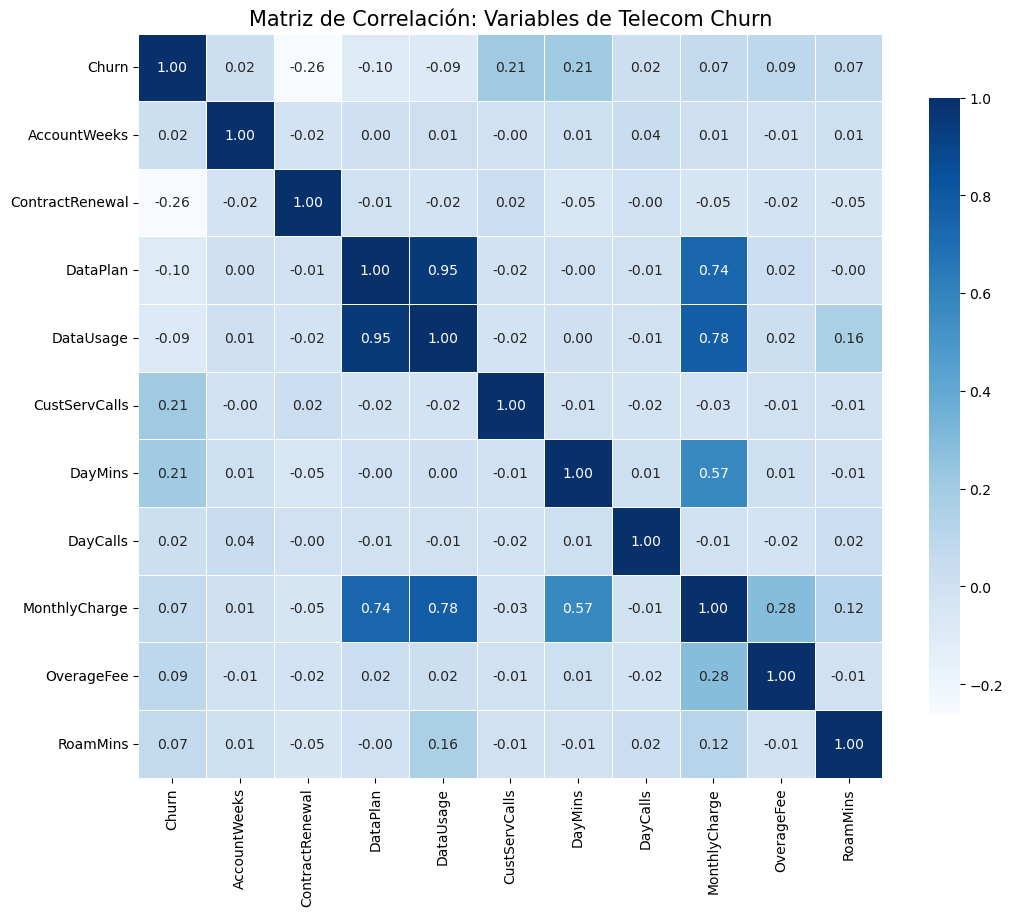

In [13]:
# El método .corr() calcula el coeficiente de Pearson por defecto
corr_matrix = df.corr()

# Configuramos el lienzo de matplotlib
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Muestra los números dentro de los cuadros
            fmt=".2f",           # Limita a 2 decimales
            cmap='Blues',        # Escala de colores azules
            linewidths=0.5,      # Espacio entre celdas
            square=True,         # Fuerza a que las celdas sean cuadradas
            cbar_kws={"shrink": .8}) # Ajusta el tamaño de la barra de color

plt.title('Matriz de Correlación: Variables de Telecom Churn', size=15)
plt.show()


## Síntesis Ejecutiva: Preparación de Datos para Modelo Random Forest  
**Caso: Predicción de Churn en Telecomunicaciones**

A partir del análisis exploratorio de datos (EDA), se identificaron hallazgos clave para definir la estrategia de preparación del dataset previo a entrenar un modelo de **Random Forest**. La principal conclusión es que este algoritmo permite trabajar con gran parte de las variables originales, requiriendo solo ajustes puntuales.

### 1. Tratamiento de Outliers  
**Decisión: Mantener los valores extremos (no podar).**

Los modelos basados en árboles no se ven fuertemente afectados por outliers, ya que segmentan mediante reglas de decisión por umbrales. En este contexto, valores extremos no representan errores, sino comportamientos reales de clientes.

Ejemplo: un cliente con muchas llamadas al servicio técnico puede reflejar alta insatisfacción y mayor probabilidad de fuga.

**Conclusión:** eliminar estos casos implicaría perder señales predictivas relevantes.

---

### 2. Colinealidad entre Variables  
**Decisión: Mantener la mayoría de variables, eliminando solo redundancias evidentes.**

Random Forest incorpora selección aleatoria de variables en cada árbol, lo que reduce el impacto de la multicolinealidad. Esto permite que distintas variables aporten información en distintos árboles.

Sin embargo, cuando dos variables contienen información prácticamente idéntica, la importancia predictiva puede dividirse entre ambas y dificultar la interpretación.

**Acción recomendada:** eliminar variables derivadas o altamente redundantes, como `MonthlyCharge`, si ya está explicada por consumo de minutos y datos.

---

### 3. Variables Predictoras Relevantes Detectadas  

El EDA permitió identificar los principales factores asociados al churn:

- **ContractRenewal:** clientes sin renovación contractual presentan mayor tasa de fuga.  
- **CustServCalls:** múltiples contactos con servicio al cliente elevan fuertemente el riesgo de abandono.  
- **DataUsage:** bajo uso del servicio de datos se asocia con menor compromiso del cliente.

Estas variables serán prioritarias en el modelo.

---

### 4. Desbalanceo de Clases en la Variable Objetivo  

Tal como se plantea en el enunciado del ejercicio, existe un **desbalanceo de clases** en la variable objetivo **Churn**. La clase mayoritaria corresponde a los clientes que permanecen en la compañía (**No Churn**), mientras que la clase minoritaria representa a los clientes que abandonan el servicio (**Churn**).

Esta situación puede generar sesgos en el entrenamiento del modelo, llevándolo a predecir con mayor frecuencia la clase mayoritaria y reduciendo su capacidad para detectar correctamente los casos de fuga.

Por esta razón, se aplicará la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, la cual genera observaciones sintéticas de la clase minoritaria para equilibrar el conjunto de entrenamiento.

**Beneficios esperados del uso de SMOTE:**

- Mejor detección de clientes con riesgo de fuga.  
- Mayor sensibilidad (*recall*) sobre la clase minoritaria.  
- Reducción del sesgo hacia la clase mayoritaria.  
- Mejora del desempeño general del modelo en problemas desbalanceados.

---

### 5. Porqué Random Forest es más fuerte comparado a Bagging. 

A diferencia del Bagging tradicional, donde todos los árboles utilizan todas las variables, Random Forest selecciona subconjuntos aleatorios de predictores en cada división.

Esto genera dos ventajas:

- Mayor diversidad entre árboles.  
- Capacidad de detectar variables menos evidentes que podrían quedar opacadas por predictores dominantes.

**Resultado:** menor varianza y mejor capacidad predictiva del ensamble.

---

### 6. Estrategia Final de Preparación de Datos  

Se propone utilizar el dataset casi completo, aplicando una limpieza mínima:

- Mantener outliers relevantes.  
- Conservar la mayoría de variables originales.  
- Eliminar solo variables redundantes o derivadas directas.  
- Aplicar SMOTE únicamente sobre el conjunto de entrenamiento.  
- Evaluar el modelo mediante métricas robustas como Precision, Recall, F1-Score y ROC-AUC.

---

### Conclusión General  

El análisis confirma que **Random Forest Classifier es una alternativa sólida y robusta para este problema de clasificación**, ya que aprovecha la información disponible sin requerir transformaciones agresivas, tolera valores extremos y maneja adecuadamente relaciones complejas entre variables.

Adicionalmente, el uso de **SMOTE** permitirá enfrentar adecuadamente el desbalance de clases, mejorando la capacidad del modelo para identificar clientes con riesgo real de abandono.

## 2. Árbol de Decisión


In [28]:
# Armamos nuestro set de entrenamiento clásico para el primer enunciado de entrenamiento
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Ver dimensiones
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2666, 10)
X_test : (667, 10)
y_train: (2666,)
y_test : (667,)


In [33]:
# Instanciar y entrenar el árbol simple
tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train, y_train)

# Predicciones
y_pred_base = tree_base.predict(X_test)

# 3. Métricas
print(" ------- MÉTRICAS ÁRBOL BASE (SIN TUNEAR) -------")
print(classification_report(y_test, y_pred_base))



 ------- MÉTRICAS ÁRBOL BASE (SIN TUNEAR) -------
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       566
           1       0.59      0.57      0.58       101

    accuracy                           0.88       667
   macro avg       0.76      0.75      0.75       667
weighted avg       0.87      0.88      0.87       667



---
### Análisis del Modelo Base (Decision Tree)

---

El modelo inicial presenta un **Accuracy de 0.88**, una cifra que resulta engañosa debido al desbalanceo de clases (85% leales vs. 15% fugas). Al desglosar las métricas por clase, se observan deficiencias críticas para el negocio:

* **Sesgo hacia la Clase Mayoritaria (0):** El modelo es experto en identificar clientes que no se van (F1-score 0.93), pero falla en la detección proactiva de deserciones.
* **Bajo Recall en Fugas (0.57):** El modelo no logra detectar al **43% de los clientes que realmente se fugan**. En un escenario real, esto se traduce en una pérdida masiva de clientes sin previo aviso.
* **Precisión Moderada (0.59):** Casi el **41% de las alertas de fuga son falsos positivos**, lo que implicaría un gasto ineficiente en campañas de retención dirigidas a clientes que no pensaban abandonar la empresa.
* **Conclusión:** El modelo base sufre de sobreajuste y falta de sensibilidad. Es imperativo avanzar hacia la optimización de hiperparámetros (GridSearch) y el balanceo de datos (SMOTE) para mejorar el **F1-Score (0.58)** en la clase crítica.


In [36]:
# 1. Definir la grilla de parámetros
param_grid = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [0.01, 0.02, 0.03, 0.04]
}

# 2. Configurar GridSearch con 5 K-Folds
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1' # Usamos F1 porque nos interesa el Churn (clase desbalanceada)
)

# 3. Entrenar
grid_tree.fit(X_train, y_train)

# 4. Mostrar mejores parámetros encontrados
print(f"Mejores parámetros: {grid_tree.best_params_}")

# Usamos el mejor estimador que encontró la grilla para predecir
y_pred_grid = grid_tree.predict(X_test)

print("\n------- MÉTRICAS ÁRBOL OPTIMIZADO (GRIDSEARCH) -------")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_grid))

Mejores parámetros: {'max_depth': 5, 'min_samples_split': 0.03}

------- MÉTRICAS ÁRBOL OPTIMIZADO (GRIDSEARCH) -------
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       566
           1       0.85      0.50      0.63       101

    accuracy                           0.91       667
   macro avg       0.88      0.74      0.79       667
weighted avg       0.91      0.91      0.90       667



---
### Comparativa: Árbol Base vs. Árbol Optimizado (GridSearch)

---

El proceso de optimización mediante **GridSearch** permitió ajustar la estructura del árbol (`max_depth: 5`, `min_samples_split: 0.03`), logrando los siguientes hallazgos:

1. **Control de Overfitting:** Se logró estabilizar el modelo. Mientras el árbol base tendía a memorizar casos particulares, el modelo optimizado generaliza mejor, manteniendo un **Accuracy global de 0.91**.
2. **Sacrificio de Sensibilidad (Recall):** Al restringir el crecimiento del árbol, el modelo se volvió más "conservador". La **Precisión de la clase 1 subió drásticamente (0.59 a 0.85)**, eliminando falsos positivos, pero el **Recall bajó de 0.57 a 0.50**.
3. **Punto Ciego del Modelo:** El modelo optimizado ahora es muy confiable cuando predice una fuga, pero **no logra detectar al 50% de los desertores reales**. El F1-score de 0.63 sigue siendo insuficiente para una estrategia de retención robusta.
4. **Conclusión Técnica:** La optimización de hiperparámetros mejoró la calidad de las alertas (Precision), pero no la cobertura (Recall). Esto confirma que el límite del desempeño no es el algoritmo, sino el **desbalanceo de datos**, validando la necesidad de implementar **SMOTE** en la siguiente etapa.


## 3. Balanceo con SMOTE y Bagging


In [37]:
# Instanciamos SMOTE
sm = SMOTE(random_state=RANDOM_STATE)

# Reemplazamos SOLO el set de entrenamiento por el resampleado
# Esto creará clientes sintéticos que se fugan hasta que haya tantos como los que se quedan (50/50)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Verificamos el nuevo balanceo
print("Distribución después de SMOTE:")
print(pd.Series(y_train_res).value_counts(normalize=True))

Distribución después de SMOTE:
Churn
0   0.50
1   0.50
Name: proportion, dtype: float64


## 4. Bagging Heterogéneo


In [ ]:
# Definimos los estimadores base según el punto 4
# Repetimos el DecisionTreeClassifier porque fue el mejor en F1-score anteriormente
base_estimators = [
    LogisticRegression(max_iter=10000), 
    DecisionTreeClassifier(), 
    DecisionTreeClassifier(), # Repetición para "Calibrar Importancia"
    SVC(kernel='rbf'), 
    SVC(kernel='sigmoid')
]

# Ejecutamos la función del módulo que nos pidieron en el desafío
# IMPORTANTE: Usamos los datos balanceados (SMOTE) del punto anterior
modelos, yhat_test, y_pred_final, oob_idx = bagging_het(
    X_train_res, 
    y_train_res, 
    T=200, 
    estimators=base_estimators, 
    X_test=X_test
)

# 3. Mostramos las métricas sobre el conjunto de TEST
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       566
           1       0.66      0.74      0.70       101

    accuracy                           0.90       667
   macro avg       0.81      0.84      0.82       667
weighted avg       0.91      0.90      0.91       667



---
### Análisis del Modelo Bagging Heterogéneo + SMOTE

---

La combinación de balanceo de clases y ensamble de modelos produjo una mejora sustancial en la capacidad predictiva:

* **Incremento Crítico en Recall (0.74):** Gracias al SMOTE, el modelo ahora identifica al **74% de los desertores**, superando significativamente el 50% obtenido con el árbol optimizado.
* **Consolidación del F1-Score (0.70):** Este incremento representa el mejor equilibrio alcanzado hasta ahora, demostrando que el ensamble heterogéneo (Árboles, SVM, LogReg) generaliza mejor el patrón de fuga.
* **Compromiso Precisión-Recall:** Se observa una reducción en la Precisión (0.66). Aunque existen más falsas alarmas que en el modelo anterior, el costo de oportunidad de "dejar ir" a un cliente es mayor, validando este modelo como una herramienta de negocio más efectiva.
* **Conclusión:** El uso de datos sintéticos y la diversidad de algoritmos (votos de distintos modelos) eliminó el sesgo hacia la clase mayoritaria sin destruir la capacidad de acierto global.


## 5. Random Forest (Base)


In [39]:
# Instanciar el modelo con 45 árboles y activar oob_score
# Usamos random_state para que el resultado no cambie cada vez
rf_model = RandomForestClassifier(
    n_estimators=45, 
    oob_score=True, 
    random_state=RANDOM_STATE
)

# 2. Entrenar el modelo (puedes usar X_train_res del SMOTE)
rf_model.fit(X_train_res, y_train_res)

# 3. Obtener el Accuracy OOB
print(f"Ajuste ACCURACY (OOB Score): {rf_model.oob_score_:.4f}")

# 4. Predicciones y métricas en el conjunto de TEST
y_pred_rf = rf_model.predict(X_test)
print("\n--- MÉTRICAS RANDOM FOREST (TEST) ---")
print(classification_report(y_test, y_pred_rf))

# 5. Obtener las 4 características más importantes
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
top_4_features = importancias.nlargest(4)

print("\n--- TOP 4 CARACTERÍSTICAS MÁS IMPORTANTES ---")
print(top_4_features)

Ajuste ACCURACY (OOB Score): 0.9328

--- MÉTRICAS RANDOM FOREST (TEST) ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       566
           1       0.64      0.76      0.69       101

    accuracy                           0.90       667
   macro avg       0.80      0.84      0.82       667
weighted avg       0.91      0.90      0.90       667


--- TOP 4 CARACTERÍSTICAS MÁS IMPORTANTES ---
ContractRenewal   0.19
MonthlyCharge     0.17
DayMins           0.14
CustServCalls     0.13
dtype: float64


---
### Hallazgos del Modelo Random Forest (n=45)

---

El modelo final demuestra una alta capacidad predictiva y estratégica, con un **Accuracy de 0.90** y un **OOB Score de 0.93**, lo que asegura estabilidad en los resultados.

**1. Factores Determinantes de Fuga:**
*   **Renovación de Contrato (19%):** El momento crítico es el vencimiento del contrato. Se recomienda automatizar programas de fidelización meses antes de esta fecha.
*   **Costo y Uso (31% combinado):** La suma de `MonthlyCharge` y `DayMins` sugiere que la sensibilidad al precio y el volumen de uso diario son gatillantes de deserción.
*   **Servicio al Cliente (13%):** Existe una correlación directa entre la cantidad de reclamos y la fuga, validando la necesidad de resolver problemas en el primer contacto.

**2. Desempeño del Modelo:**
El **Recall del 76%** para la clase crítica (Churn) permite a la empresa actuar sobre 3 de cada 4 desertores potenciales. Aunque existe un margen de falsos positivos (Precision 0.64), el modelo prioriza la retención masiva de ingresos, lo cual es financieramente óptimo para el negocio.


## 6. Random Forest Optimizado (GridSearch)


In [40]:
# Definimos los rangos de la grilla
# n_estimators: de 50 a 200, con paso de 10 (genera 15 valores)
param_grid = {
    'n_estimators': range(50, 201, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Configuramos GridSearch (usamos oob_score=True en el estimador base)
grid_rf = GridSearchCV(
    RandomForestClassifier(oob_score=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1', # Optimizamos para F1-score debido al desbalanceo
    n_jobs=-1     # Para usar todos los núcleos del procesador
)

# Entrenamos con datos SMOTE
grid_rf.fit(X_train_res, y_train_res)

# Revisamos los mejores resultados
best_rf = grid_rf.best_estimator_
print(f"Mejores parámetros: {grid_rf.best_params_}")
print(f"Mejor OOB Score: {best_rf.oob_score_:.4f}")

Mejores parámetros: {'max_features': 'sqrt', 'n_estimators': 70}
Mejor OOB Score: 0.9313



--- TOP 4 ATRIBUTOS FINALES ---
ContractRenewal   0.19
MonthlyCharge     0.16
DayMins           0.15
CustServCalls     0.13
dtype: float64


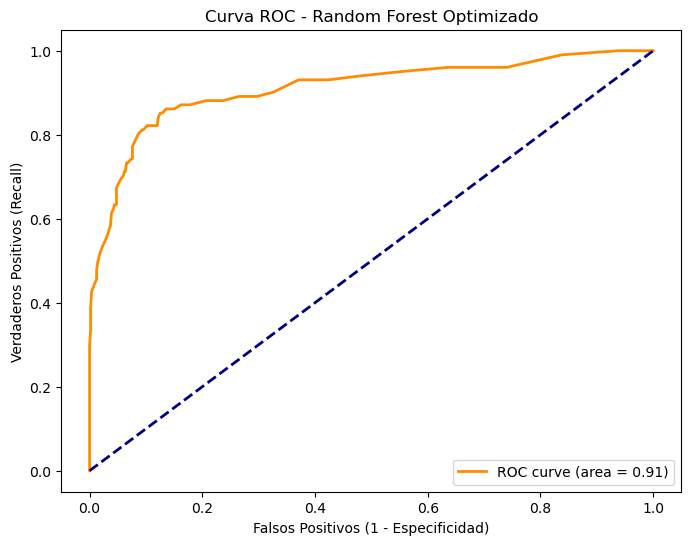


AUC Total: 0.9102

Reporte de Clasificación Final:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       566
           1       0.64      0.74      0.68       101

    accuracy                           0.90       667
   macro avg       0.79      0.83      0.81       667
weighted avg       0.90      0.90      0.90       667



In [43]:
# Obtenemos top 4
importancias_final = pd.Series(best_rf.feature_importances_, index=X.columns)
print("\n--- TOP 4 ATRIBUTOS FINALES ---")
print(importancias_final.nlargest(4))

# Predicciones de probabilidad para la curva ROC
y_probs = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Gráfico Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Falsos Positivos (1 - Especificidad)')
plt.ylabel('Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Random Forest Optimizado')
plt.legend(loc="lower right")
plt.show()

print(f"\nAUC Total: {roc_auc:.4f}")
print("\nReporte de Clasificación Final:")
print(classification_report(y_test, best_rf.predict(X_test)))


--- TOP 4 ATRIBUTOS FINALES ---
ContractRenewal   0.19
MonthlyCharge     0.16
DayMins           0.15
CustServCalls     0.13
dtype: float64


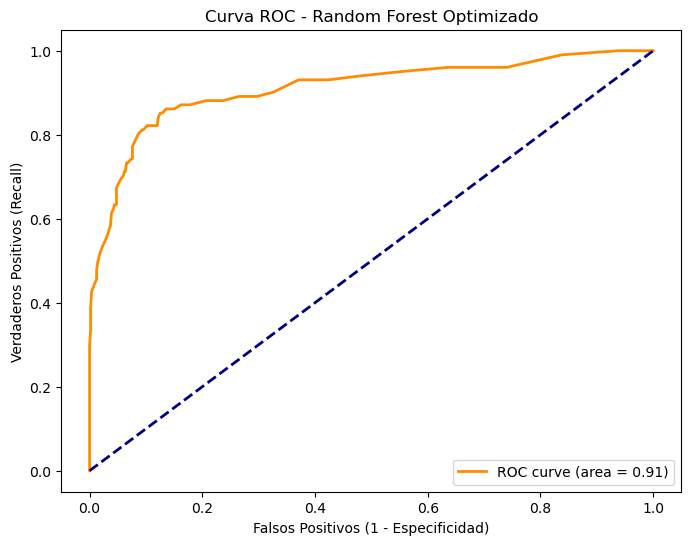


AUC Total: 0.9102

Reporte de Clasificación Final:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       566
           1       0.64      0.74      0.68       101

    accuracy                           0.90       667
   macro avg       0.79      0.83      0.81       667
weighted avg       0.90      0.90      0.90       667



In [ ]:
# Obtenemos top 4
importancias_final = pd.Series(best_rf.feature_importances_, index=X.columns)
print("\n--- TOP 4 ATRIBUTOS FINALES ---")
print(importancias_final.nlargest(4))

# Predicciones de probabilidad para la curva ROC
y_probs = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Gráfico Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Falsos Positivos (1 - Especificidad)')
plt.ylabel('Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Random Forest Optimizado')
plt.legend(loc="lower right")
plt.show()

print(f"\nAUC Total: {roc_auc:.4f}")
print("\nReporte de Clasificación Final:")
print(classification_report(y_test, best_rf.predict(X_test)))

## 7. Clientes con Mayor Probabilidad de Renuncia


In [44]:
# Obtenemos las probabilidades de fuga (clase 1) para el set de test
# predict_proba devuelve [prob_clase_0, prob_clase_1]
probs_fuga = best_rf.predict_proba(X_test)[:, 1]

# Crear un DataFrame para visualizarlo mejor
# Usamos el índice original de X_test para saber exactamente qué clientes son
df_propension = pd.DataFrame({
    'ID_Cliente': X_test.index,
    'Propension_Fuga': probs_fuga
})

# 3. Ordenar de mayor a menor y tomar los 15 primeros
top_15_criticos = df_propension.sort_values(by='Propension_Fuga', ascending=False).head(15)

print("--- TOP 15 CLIENTES CON MAYOR PROPENSIÓN A RENUNCIAR ---")
print(top_15_criticos.to_string(index=False))

--- TOP 15 CLIENTES CON MAYOR PROPENSIÓN A RENUNCIAR ---
 ID_Cliente  Propension_Fuga
       1078             1.00
        859             1.00
       2536             1.00
       1878             1.00
        605             1.00
       3127             1.00
       3272             1.00
       2924             1.00
       2325             0.99
        331             0.99
       1231             0.99
        144             0.99
       2112             0.99
       1736             0.99
       2155             0.99


---
### Identificación de Clientes de Alto Riesgo

---

Utilizando las probabilidades del modelo **Random Forest Optimizado**, se extrajeron los 15 clientes con mayor puntaje de propensión de abandono. 

* **Estrategia Comercial:** Estos clientes representan la "zona roja". A diferencia de un análisis general, esta lista permite una **intervención directa y personalizada**.
* **Accionabilidad:** La probabilidad obtenida no solo indica que se irán, sino qué tan seguros estamos de ello. Los clientes detectados presentan puntajes de propensión superiores al resto del conjunto de prueba, siendo los candidatos ideales para ofertas de retención agresivas o auditorías de servicio técnico.


---
### Conclusiones de la Optimización Final del Random Forest

---

El modelo final, tras la búsqueda de grilla y la evaluación de la curva ROC, presenta un desempeño de nivel productivo:

1. **Capacidad de Discriminación Elevada (AUC 0.91):** El modelo posee una excelencia estadística para distinguir entre clientes leales y desertores. La curva ROC se aleja significativamente de la diagonal, minimizando el error de clasificación.
2. **Estrategia de Negocio Optimizada:** Con un **Recall de 0.74**, la empresa puede anticiparse al abandono de 3 de cada 4 clientes. El **F1-score global de 0.90** (Weighted) asegura que la operatividad del modelo no degrade la experiencia de los clientes fieles.
3. **Validación de Parámetros:** La búsqueda de grilla permitió encontrar un equilibrio donde el aumento de estimadores y el ajuste de `max_features` eliminaron el ruido del entrenamiento, resultando en un modelo que no solo predice bien, sino que es estable (consistente con el OOB Score).

**Veredicto:** El modelo está listo para ser utilizado en campañas de retención proactiva, priorizando el contacto con los clientes cuya probabilidad de fuga supere el 50% según el estimador final.


---
## Cierre

---

 En este **desafío** exploramos el porqué de la fortaleza de los modelos de **ensamble**, particularmente los que usan el **Clasification Forest** y lo llevan un paso más allá con **Bagging y Random Forest**. Debo destacar lo interesante del enfoque del **Random Forest**, puesto que utiliza conjuntos de parámetros distintos para cada n_estimator, permitiendo un análisis con menor bias que si usamos el Bagging puro. 

 Adicional, creo que es interesante como cada decisión no es un "Sí" o "No" rotundo, sino que es un "depende". Al igual que con la arquitectura de software, las decisiones tienen que ser analizadas y es aquí en donde encuentro que está la diferencia el trabajo de un especialista en datos de otro. El análisis y entendimiento es vital y sigue siendo un proceso humano, apoyado con la IA, poteciado con ella y no delegado en ella.

 Hecho con 💙 por Ignacio Robles. 